# 04 — Results & Analysis

**Course:** Machine Learning and Deep Learning (CBS, Spring 2026)
**Companion to:** `gameplan.md`, `01_eda_andreja.ipynb`, `02_preprocessing_andreja.ipynb`, `03_modeling_andreja.ipynb`

This notebook turns the trained models and saved predictions into the figures and tables that go into the final Word report. It directly answers the three research questions:

- **RQ1 (predictive):** which model family wins, and by how much?
- **RQ2 (explanatory):** which of the six feature categories drives prediction?
- **RQ3 (cross-national):** which countries are hardest to classify?

**Inputs (produced by `03_modeling_andreja.ipynb`):**

- `predictions_A.csv`, `predictions_B.csv` — test-set probabilities for all 4 models.
- `splits/{train,val,test}_idx.npy` — exact split indices.
- `models/<model>_<set>.joblib` (and `.keras` for the FFNN).
- `feature_set_A.csv`, `feature_set_B.csv` — to reconstruct the test-set X matrices.

**Outputs (saved next to this notebook):**

A `results/` folder with PNG figures, CSV tables, and a final `summary.json` of headline numbers.


## 0. Setup


In [1]:
import os, time, json, joblib, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

Path('results').mkdir(exist_ok=True)
print('Setup complete. Output dir: results/')


Setup complete. Output dir: results/


## 1. Load all inputs from the modeling notebook


In [2]:
# Predictions on the test set (from 03_modeling_andreja.ipynb)
pred_A = pd.read_csv('predictions_A.csv')
pred_B = pd.read_csv('predictions_B.csv')
print(f'predictions_A: {pred_A.shape}  columns: {list(pred_A.columns)}')
print(f'predictions_B: {pred_B.shape}  columns: {list(pred_B.columns)}')

# Test-set indices
idx_train = np.load('splits/train_idx.npy')
idx_val   = np.load('splits/val_idx.npy')
idx_test  = np.load('splits/test_idx.npy')
print(f'\nTest set: {len(idx_test):,} rows')

# Feature sets (used for X_test reconstruction and feature importance)
set_A = pd.read_csv('feature_set_A.csv')
set_B = pd.read_csv('feature_set_B.csv')

y_test = set_A['vote'].iloc[idx_test].reset_index(drop=True)
assert (y_test.values == pred_A['y_true'].values).all(), 'y_test mismatch!'
print('y_test matches predictions: OK')


predictions_A: (6971, 4)  columns: ['y_true', 'lr', 'rf', 'gbm']
predictions_B: (6971, 4)  columns: ['y_true', 'lr', 'rf', 'gbm']

Test set: 6,971 rows
y_test matches predictions: OK


In [3]:
# Load trained sklearn pipelines (LR, RF, GBM × Set A, Set B).
# No TensorFlow import — this project deliberately uses 3 classical models;
# see §10 of 03_modeling_andreja.ipynb for the rationale.
models = {'A': {}, 'B': {}}

for name in ['lr', 'rf', 'gbm']:
    for s in ['A', 'B']:
        f = f'models/{name}_{s}.joblib'
        if os.path.exists(f):
            models[s][name] = joblib.load(f)
        else:
            print(f'  MISSING: {f}  — re-run 03_modeling_andreja.ipynb')

HAS_FFNN = False  # never True in this project

print('Loaded models per set:')
for s in ['A', 'B']:
    print(f'  Set {s}: {list(models[s].keys())}')


Loaded models per set:
  Set A: ['lr', 'rf', 'gbm']
  Set B: ['lr', 'rf', 'gbm']


## 2. Reconstruct X_test for both feature sets

Permutation importance and SHAP need the actual test-set features, not just predictions.


In [4]:
def get_xy_test(df_set):
    feats = [c for c in df_set.columns if c != 'vote']
    return df_set[feats].iloc[idx_test].reset_index(drop=True), \
           df_set['vote'].iloc[idx_test].reset_index(drop=True)

X_test_A, _ = get_xy_test(set_A)
X_test_B, _ = get_xy_test(set_B)
print(f'X_test_A: {X_test_A.shape}')
print(f'X_test_B: {X_test_B.shape}')


X_test_A: (6971, 22)
X_test_B: (6971, 15)


## 3. Test-set metric summary (RQ1)

The headline table for the report. Key metric is **PR-AUC** (right metric under 78/22 imbalance), with F1 and recall on the **minority class** ("did not vote") as secondary metrics — that's where misclassification matters.


In [5]:
# CHANGE #3: report metrics at both default 0.5 AND the tuned threshold.
import json, os

def compute_metrics(y_true, proba, label, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        'model':              label,
        'threshold':          round(threshold, 3),
        'pr_auc':             average_precision_score(y_true, proba),
        'roc_auc':            roc_auc_score(y_true, proba),
        'accuracy':           accuracy_score(y_true, pred),
        'precision_minority': precision_score(y_true, pred, pos_label=0, zero_division=0),
        'recall_minority':    recall_score(y_true, pred, pos_label=0, zero_division=0),
        'f1_minority':        f1_score(y_true, pred, pos_label=0, zero_division=0),
        'brier':              brier_score_loss(y_true, proba),
    }

# Load tuned thresholds if 03_modeling_andreja.ipynb wrote them
tuned = {}
if os.path.exists('tuned_thresholds.json'):
    with open('tuned_thresholds.json') as f:
        tuned = json.load(f)
    print(f'Loaded tuned thresholds: {tuned}')
else:
    print('No tuned_thresholds.json found — reporting only default-threshold metrics.')

rows = []
for s, df in [('A', pred_A), ('B', pred_B)]:
    for col in df.columns:
        if col == 'y_true':
            continue
        # default 0.5
        rows.append({**compute_metrics(df['y_true'], df[col],
                                        f'{col.upper()} ({s})', threshold=0.5),
                     'set': s, 'algo': col})
        # tuned (if available)
        t_key = f'{col}_{s}'
        if t_key in tuned:
            rows.append({**compute_metrics(df['y_true'], df[col],
                                            f'{col.upper()} ({s}) tuned',
                                            threshold=tuned[t_key]),
                         'set': s, 'algo': col})

metrics_df = pd.DataFrame(rows)[
    ['model', 'algo', 'set', 'threshold', 'pr_auc', 'roc_auc', 'accuracy',
     'precision_minority', 'recall_minority', 'f1_minority', 'brier']
].sort_values('pr_auc', ascending=False).reset_index(drop=True)

print()
print(metrics_df.round(4).to_string(index=False))
metrics_df.to_csv('results/test_metrics.csv', index=False)

  model algo set  pr_auc  roc_auc  accuracy  precision_minority  recall_minority  f1_minority  brier
GBM (A)  gbm   A  0.9317   0.8097    0.7204              0.4224           0.7525       0.5411 0.1783
GBM (B)  gbm   B  0.9314   0.8087    0.7223              0.4249           0.7577       0.5445 0.1787
 LR (B)   lr   B  0.9285   0.8010    0.7118              0.4143           0.7629       0.5370 0.1842
 LR (A)   lr   A  0.9284   0.8011    0.7104              0.4126           0.7610       0.5351 0.1841
 RF (A)   rf   A  0.9271   0.7961    0.7345              0.4345           0.7033       0.5371 0.1718
 RF (B)   rf   B  0.9270   0.7978    0.7326              0.4330           0.7132       0.5388 0.1719


## 4. ROC and PR curves (Figure 1)

Two side-by-side panels: ROC curves on the left, PR curves on the right. We overlay all 8 model × set combinations.


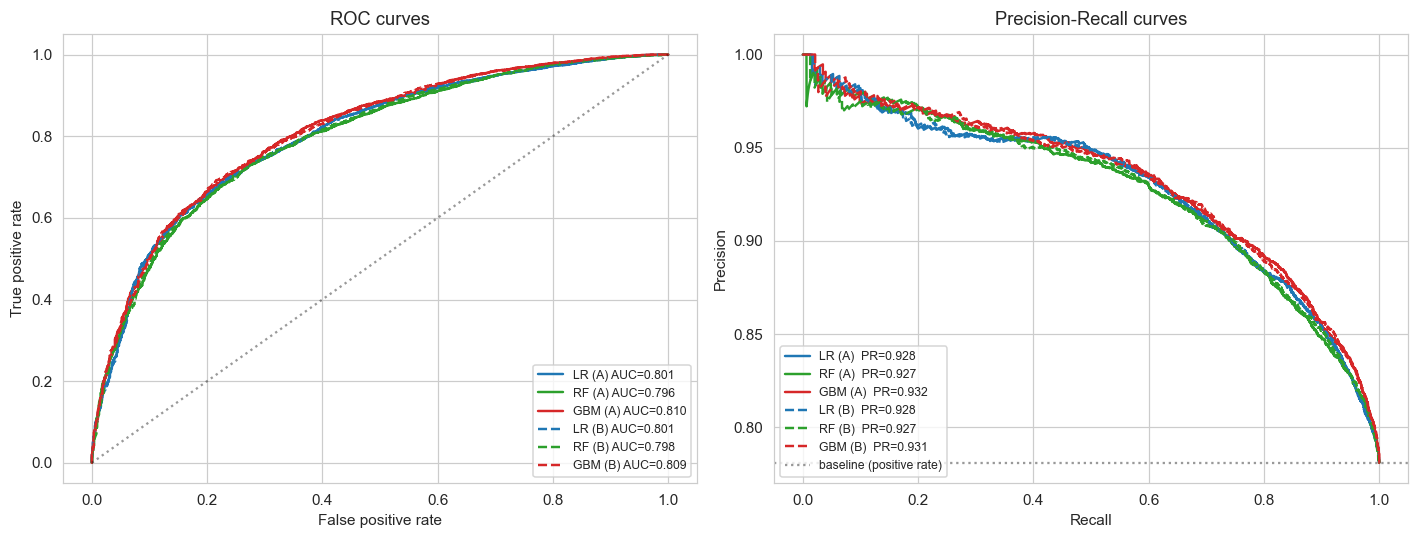

In [6]:
COLORS = {'lr': '#1f77b4', 'rf': '#2ca02c', 'gbm': '#d62728'}
LINESTYLES = {'A': '-', 'B': '--'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for set_name, pred_df in [('A', pred_A), ('B', pred_B)]:
    for algo in [c for c in pred_df.columns if c != 'y_true']:
        proba = pred_df[algo]
        fpr, tpr, _ = roc_curve(pred_df['y_true'], proba)
        prec, rec, _ = precision_recall_curve(pred_df['y_true'], proba)
        roc = roc_auc_score(pred_df['y_true'], proba)
        pr  = average_precision_score(pred_df['y_true'], proba)
        label = f'{algo.upper()} ({set_name})  PR={pr:.3f}'
        axes[0].plot(fpr, tpr,
                     color=COLORS.get(algo, '#888'),
                     linestyle=LINESTYLES[set_name], linewidth=1.6,
                     label=f'{algo.upper()} ({set_name}) AUC={roc:.3f}')
        axes[1].plot(rec, prec,
                     color=COLORS.get(algo, '#888'),
                     linestyle=LINESTYLES[set_name], linewidth=1.6,
                     label=label)

axes[0].plot([0, 1], [0, 1], 'k:', alpha=0.4)
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves')
axes[0].legend(loc='lower right', fontsize=8)

axes[1].axhline(pred_A['y_true'].mean(), color='k', ls=':', alpha=0.4,
                label=f'baseline (positive rate)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curves')
axes[1].legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.savefig('results/fig1_roc_pr_curves.png', dpi=200, bbox_inches='tight')
plt.show()


## 5. Confusion matrices (Figure 4)

One small panel per model × set. Threshold is the default 0.5; the report should note that this can be tuned for higher minority-class recall if needed.


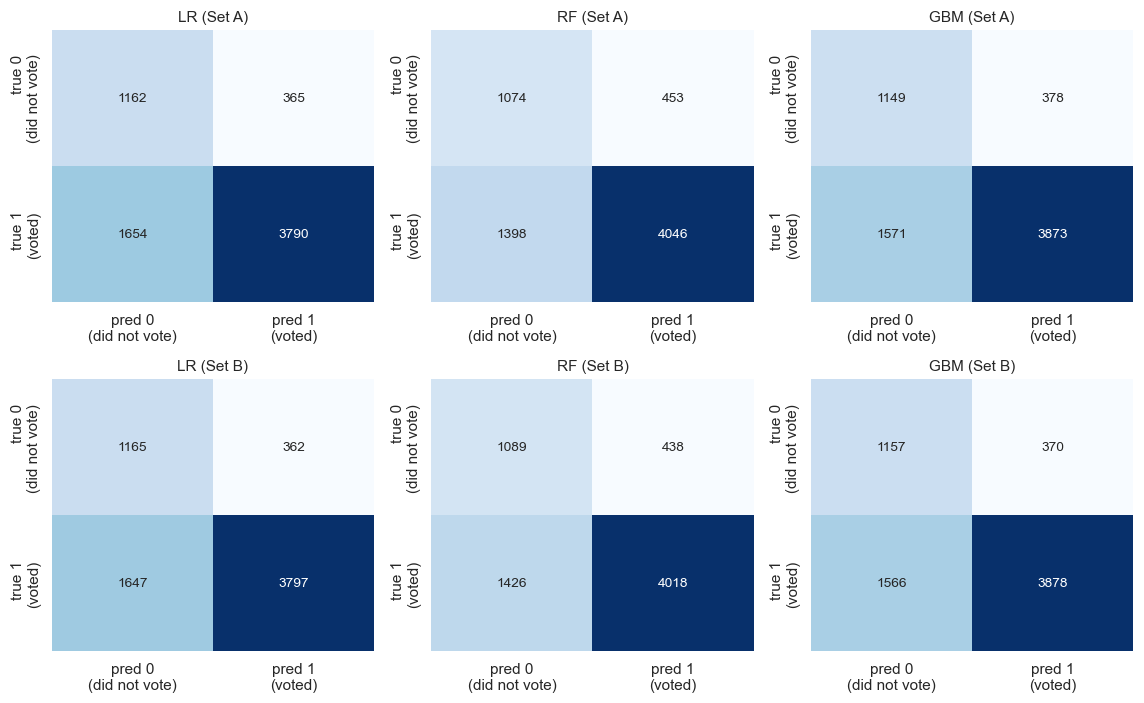

In [7]:
def plot_confusion(ax, y_true, proba, title):
    pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['pred 0\n(did not vote)', 'pred 1\n(voted)'],
                yticklabels=['true 0\n(did not vote)', 'true 1\n(voted)'],
                cbar=False, annot_kws={'fontsize': 9})
    ax.set_title(title, fontsize=10)

algos = [c for c in pred_A.columns if c != 'y_true']
n_rows = 2  # A, B
n_cols = len(algos)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 6.5))
if n_cols == 1: axes = axes.reshape(2, 1)

for j, algo in enumerate(algos):
    plot_confusion(axes[0, j], pred_A['y_true'], pred_A[algo], f'{algo.upper()} (Set A)')
    plot_confusion(axes[1, j], pred_B['y_true'], pred_B[algo], f'{algo.upper()} (Set B)')

plt.tight_layout()
plt.savefig('results/fig4_confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()


## 6. Calibration (probability quality)

A well-calibrated model says "70 % chance of voting" only when the actual rate is around 70 %. Tree-based ensembles are often *uncalibrated* by default (probabilities are too extreme), while logistic regression is naturally well-calibrated.


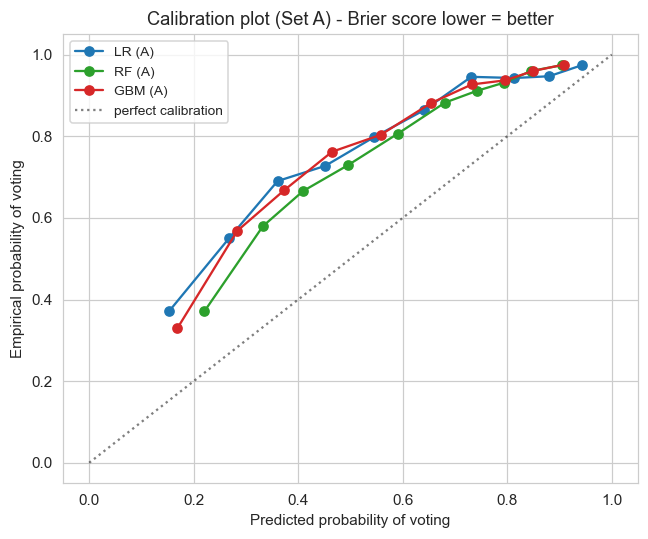

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
for set_name, pred_df in [('A', pred_A)]:  # one set is enough — they're nearly identical
    for algo in [c for c in pred_df.columns if c != 'y_true']:
        prob_true, prob_pred = calibration_curve(pred_df['y_true'], pred_df[algo],
                                                  n_bins=10, strategy='quantile')
        ax.plot(prob_pred, prob_true, marker='o', linewidth=1.5,
                color=COLORS.get(algo, '#888'),
                label=f'{algo.upper()} ({set_name})')

ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='perfect calibration')
ax.set_xlabel('Predicted probability of voting')
ax.set_ylabel('Empirical probability of voting')
ax.set_title('Calibration plot (Set A) - Brier score lower = better')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('results/fig_calibration.png', dpi=200, bbox_inches='tight')
plt.show()


## 7. RQ2 — Which feature *categories* matter most? (Figure 2)

This is the key explanatory result. We compute **permutation importance** on the test set, then **sum the importances within each of the six conceptual categories** from the gameplan. The category that loses the most predictive performance when shuffled is the one that matters most.

We use Set B (composite indices) because the categories map 1-to-1 with conceptually meaningful blocks; for Set A we'd have to sum 4 trust columns, 3 efficacy, 3 satisfaction items.


In [9]:
# Feature → category mapping for both sets
FEATURE_GROUPS_A = {
    'socio_demographic':  ['agea', 'gndr', 'cntry'],
    'socio_economic':     ['eduyrs', 'hinctnta', 'hinctnta_was_missing'],
    'political_interest': ['polintr', 'lrscale', 'lr_extreme', 'clsprty'],
    'institutional_trust':['trstprl', 'trstplt', 'trstprt', 'trstlgl'],
    'civic_engagement':   ['contplt', 'sgnptit', 'cptppola', 'psppsgva', 'psppipla'],
    'satisfaction':       ['stfdem', 'stfgov', 'stfeco'],
}

FEATURE_GROUPS_B = {
    'socio_demographic':  ['agea', 'gndr', 'cntry'],
    'socio_economic':     ['eduyrs', 'hinctnta', 'hinctnta_was_missing'],
    'political_interest': ['polintr', 'lrscale', 'lr_extreme', 'clsprty'],
    'institutional_trust':['trust_index'],
    'civic_engagement':   ['contplt', 'sgnptit', 'efficacy_index'],
    'satisfaction':       ['satisfaction_index'],
}

# Sanity-check that every feature is in exactly one group
for name, groups, df in [('A', FEATURE_GROUPS_A, set_A), ('B', FEATURE_GROUPS_B, set_B)]:
    flat = [v for vs in groups.values() for v in vs]
    cols = [c for c in df.columns if c != 'vote']
    missing = set(cols) - set(flat)
    extra   = set(flat) - set(cols)
    assert not missing and not extra, f'Set {name} mismatch: missing={missing} extra={extra}'
print('Feature → category mapping checks pass for both sets.')


Feature → category mapping checks pass for both sets.


In [10]:
def perm_importance(model, X_test, y_test, n_repeats=5, sample=5000):
    """Permutation importance with optional random subsample for speed."""
    if sample is not None and len(X_test) > sample:
        idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), sample, replace=False)
        X_use = X_test.iloc[idx]; y_use = y_test.iloc[idx]
    else:
        X_use, y_use = X_test, y_test
    r = permutation_importance(model, X_use, y_use, n_repeats=n_repeats,
                               scoring='average_precision',
                               random_state=RANDOM_STATE, n_jobs=-1)
    return pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

# Compute permutation importance for the best-performing tree-based model on each set.
# We use the model with highest test PR-AUC among LR/RF/GBM (skipping FFNN — would need a wrapper).
def best_sklearn_model(s):
    best_algo, best_pr = None, -1
    for algo in ['lr', 'rf', 'gbm']:
        if algo not in models[s]: continue
        pr = average_precision_score(y_test, pred_A[algo] if s=='A' else pred_B[algo])
        if pr > best_pr:
            best_pr, best_algo = pr, algo
    return best_algo, best_pr

best_A_algo, best_A_pr = best_sklearn_model('A')
best_B_algo, best_B_pr = best_sklearn_model('B')
print(f'Best sklearn model on Set A: {best_A_algo.upper()} (PR-AUC={best_A_pr:.4f})')
print(f'Best sklearn model on Set B: {best_B_algo.upper()} (PR-AUC={best_B_pr:.4f})')


Best sklearn model on Set A: GBM (PR-AUC=0.9317)
Best sklearn model on Set B: GBM (PR-AUC=0.9314)


In [11]:
# Compute permutation importance for both sets
print('Running permutation importance (sample=5000, n_repeats=5)...\n')

imp_A = perm_importance(models['A'][best_A_algo], X_test_A, y_test)
imp_B = perm_importance(models['B'][best_B_algo], X_test_B, y_test)

# Aggregate to category level
def category_importance(imp_series, groups):
    return pd.Series({
        cat: imp_series.reindex(vars_, fill_value=0).sum()
        for cat, vars_ in groups.items()
    }).sort_values(ascending=True)   # ascending for horizontal bar chart

cat_A = category_importance(imp_A, FEATURE_GROUPS_A)
cat_B = category_importance(imp_B, FEATURE_GROUPS_B)

print('Category-level permutation importance (drop in PR-AUC when shuffled):\n')
print('Set A:'); print(cat_A.round(4))
print('\nSet B:'); print(cat_B.round(4))


Running permutation importance (sample=5000, n_repeats=5)...

Category-level permutation importance (drop in PR-AUC when shuffled):

Set A:
institutional_trust    0.0003
satisfaction           0.0006
socio_economic         0.0037
civic_engagement       0.0039
socio_demographic      0.0237
political_interest     0.0450
dtype: float64

Set B:
satisfaction           0.0003
institutional_trust    0.0011
civic_engagement       0.0031
socio_economic         0.0038
socio_demographic      0.0242
political_interest     0.0460
dtype: float64


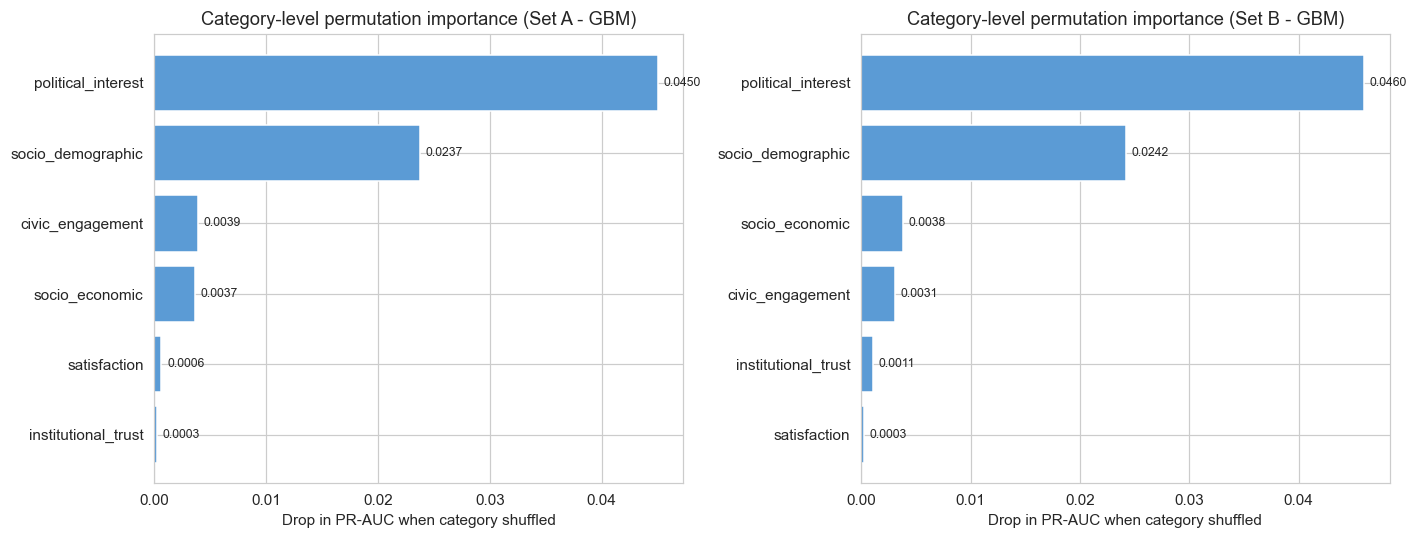

In [12]:
# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cat_imp, label in [(axes[0], cat_A, f'Set A - {best_A_algo.upper()}'),
                            (axes[1], cat_B, f'Set B - {best_B_algo.upper()}')]:
    ax.barh(cat_imp.index, cat_imp.values, color='#5b9bd5', edgecolor='white')
    ax.set_xlabel('Drop in PR-AUC when category shuffled')
    ax.set_title(f'Category-level permutation importance ({label})')
    for i, v in enumerate(cat_imp.values):
        ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('results/fig2_category_importance.png', dpi=200, bbox_inches='tight')
plt.show()

# Save the numbers for the report
pd.DataFrame({'set_A': cat_A, 'set_B': cat_B}).to_csv('results/category_importance.csv')


## 8. Variable-level importance (top 15)

Same numbers, just not aggregated. This helps the Discussion section: even if a category dominates, a single variable inside it might be doing most of the work.


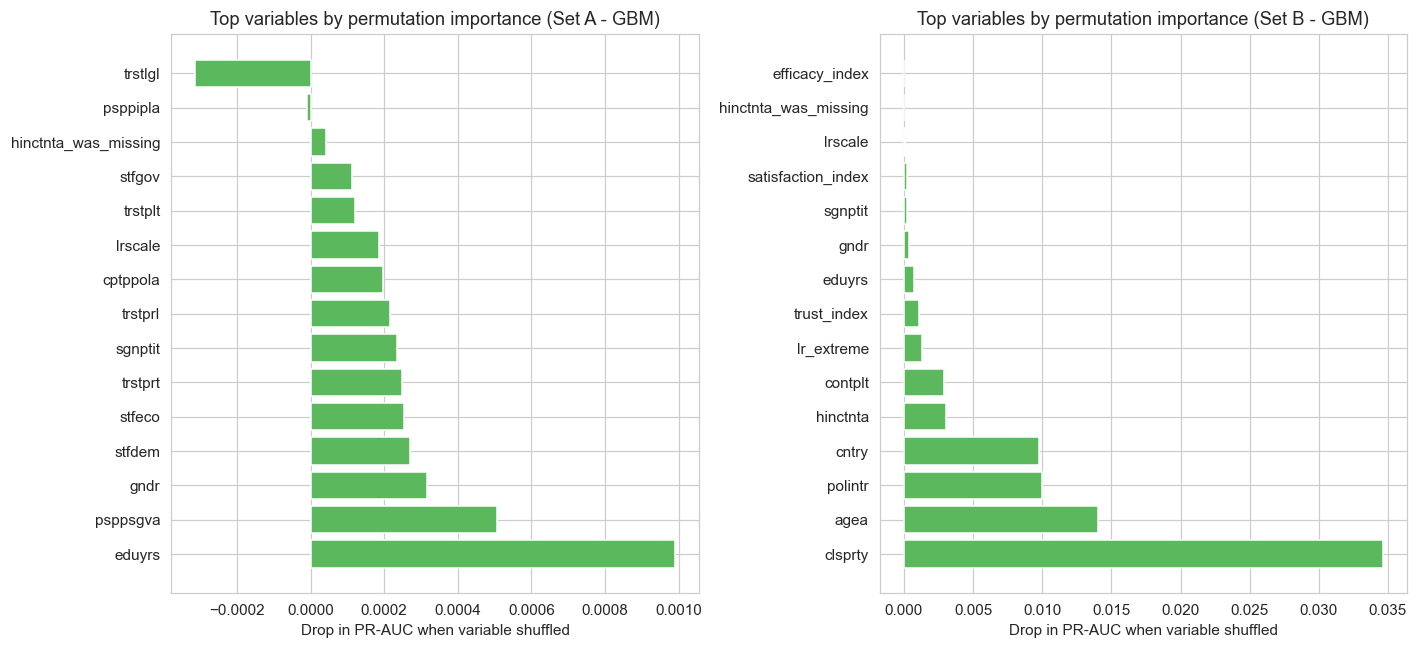

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, imp, label in [(axes[0], imp_A.tail(15), f'Set A - {best_A_algo.upper()}'),
                        (axes[1], imp_B.tail(15), f'Set B - {best_B_algo.upper()}')]:
    ax.barh(imp.index, imp.values, color='#5cb85c', edgecolor='white')
    ax.set_xlabel('Drop in PR-AUC when variable shuffled')
    ax.set_title(f'Top variables by permutation importance ({label})')

plt.tight_layout()
plt.savefig('results/fig_variable_importance.png', dpi=200, bbox_inches='tight')
plt.show()

pd.DataFrame({'set_A': imp_A, 'set_B': imp_B}).to_csv('results/variable_importance.csv')


## 9. Logistic regression coefficients (interpretability)

LR is the most interpretable model. After standardisation, coefficients are directly comparable: a +0.5 coefficient means a one-SD increase in that feature multiplies the **odds** of voting by `exp(0.5) ≈ 1.65`.

We report Set B (composite indices) since the composite columns are easier to interpret than 4 separate trust items.


Top non-country coefficients (Set B, LR):
clsprty                 0.601
polintr                 0.425
agea                    0.419
(intercept)             0.408
eduyrs                  0.238
hinctnta                0.225
contplt                 0.182
lr_extreme              0.167
trust_index             0.155
sgnptit                 0.117
gndr                   -0.080
hinctnta_was_missing   -0.038
lrscale                 0.027
efficacy_index          0.011
satisfaction_index      0.002


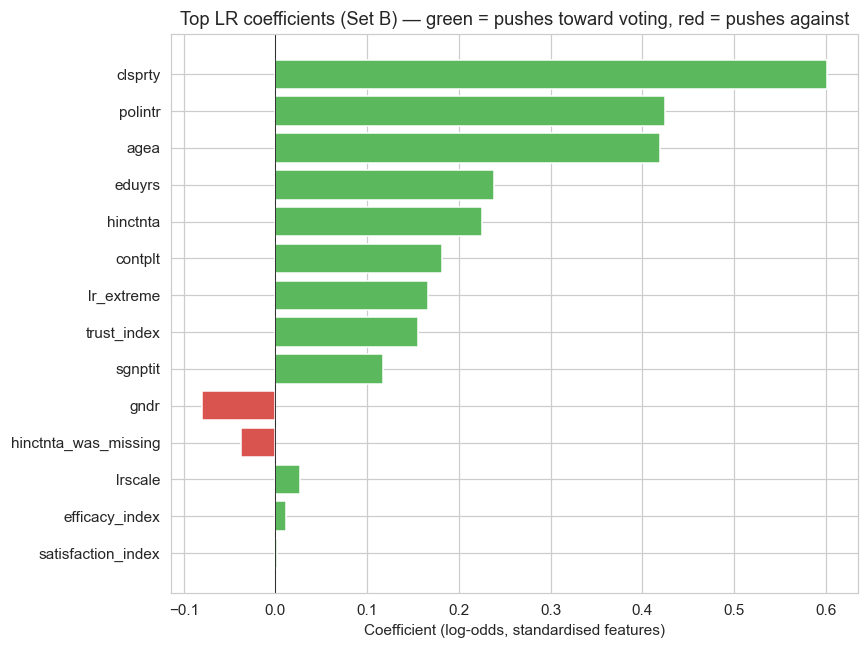

In [14]:
# Pull coefficients from the LR pipeline (Set B)
lr_pipe = models['B']['lr']
pre = lr_pipe.named_steps['pre']
clf = lr_pipe.named_steps['clf']

# Recover feature names from the ColumnTransformer
def get_feature_names(pre):
    names = []
    for name, trans, cols in pre.transformers_:
        if name == 'num':
            names.extend(cols)
        elif name == 'cat':
            names.extend(trans.get_feature_names_out(cols))
    return names

feat_names = get_feature_names(pre)
coefs = pd.Series(clf.coef_.ravel(), index=feat_names)
coefs['(intercept)'] = clf.intercept_[0]

# Highlight the non-country coefficients first
non_country = coefs[~coefs.index.str.startswith('cntry_')].sort_values(key=abs, ascending=False)
print('Top non-country coefficients (Set B, LR):')
print(non_country.round(3).to_string())

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
top_n = non_country.drop('(intercept)').head(15)[::-1]
ax.barh(top_n.index, top_n.values,
        color=['#d9534f' if v < 0 else '#5cb85c' for v in top_n.values],
        edgecolor='white')
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('Coefficient (log-odds, standardised features)')
ax.set_title('Top LR coefficients (Set B) — green = pushes toward voting, red = pushes against')
plt.tight_layout()
plt.savefig('results/fig_lr_coefficients.png', dpi=200, bbox_inches='tight')
plt.show()


## 10. SHAP analysis on the best tree model (Figure 3)

SHAP gives per-respondent feature contributions and a global ranking that's typically more reliable than Gini importance. We use `TreeExplainer` (fast, exact for tree ensembles) on whichever of RF/GBM won on Set B.

> Requires `pip install shap`. If unavailable, this cell prints a notice and the rest of the notebook still runs.


In [16]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 14.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]1/3 [numpy]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires packaging<25,>=20, but you have packaging 26.2 which is incompatible.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.
tensorflow 2.21.0 requires h5py<3.15.0,>=3.11.0, but you have h5py 3.16.0 which is incompatible.
tensorflow 2.21.0 requires keras>=3.12.0, but you have keras 3.7.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages

In [17]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('SHAP not installed. Run: pip install shap')

if HAS_SHAP and best_B_algo in ('rf', 'gbm'):
    # Get the trained classifier and the preprocessor from the pipeline
    pipe = models['B'][best_B_algo]
    pre  = pipe.named_steps['pre']
    clf  = pipe.named_steps['clf']

    # Apply the same encoding the model saw during training
    X_proc = pre.transform(X_test_B)
    feat_names_tree = get_feature_names(pre)

    # Subsample for speed
    sample_size = 1000
    idx = np.random.RandomState(RANDOM_STATE).choice(len(X_proc), sample_size, replace=False)
    X_sample = pd.DataFrame(X_proc[idx], columns=feat_names_tree)

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):     # binary classifier returns list
        shap_values = shap_values[1]      # class 1 = voted

    plt.figure()
    shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False, max_display=15)
    plt.title(f'SHAP feature importance ({best_B_algo.upper()} on Set B)')
    plt.tight_layout()
    plt.savefig('results/fig3a_shap_bar.png', dpi=200, bbox_inches='tight')
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
    plt.title(f'SHAP per-feature distribution ({best_B_algo.upper()} on Set B)')
    plt.tight_layout()
    plt.savefig('results/fig3b_shap_summary.png', dpi=200, bbox_inches='tight')
    plt.show()
elif HAS_SHAP:
    print(f'Skipping SHAP — best model on Set B is LR (use coefficients in §9 instead).')


SHAP not installed. Run: pip install shap


## 11. RQ3 — Which countries are hardest to classify? (Figure 5)

Per-country **recall on the minority class** (i.e. correctly identifying those who did NOT vote). Low recall means the model is over-predicting voting in that country.


In [18]:
# Reattach country to the test predictions
cntry_test = set_A['cntry'].iloc[idx_test].reset_index(drop=True)
best_proba = pred_B[best_B_algo].values   # use the best model on Set B
best_pred  = (best_proba >= 0.5).astype(int)

per_cntry = pd.DataFrame({
    'cntry': cntry_test,
    'y':     y_test.values,
    'pred':  best_pred,
})

def per_country_metrics(g):
    return pd.Series({
        'n':                 len(g),
        'turnout_actual %':  100 * g.y.mean(),
        'turnout_pred %':    100 * g.pred.mean(),
        'accuracy':          accuracy_score(g.y, g.pred),
        'recall_minority':   recall_score(g.y, g.pred, pos_label=0, zero_division=0),
        'precision_minority':precision_score(g.y, g.pred, pos_label=0, zero_division=0),
    })

cntry_table = (per_cntry.groupby('cntry').apply(per_country_metrics)
                       .sort_values('recall_minority'))
print(cntry_table.round(3))
cntry_table.to_csv('results/per_country_metrics.csv')


           n  turnout_actual %  turnout_pred %  accuracy  recall_minority  \
cntry                                                                       
NO     195.0            90.256          91.282     0.877            0.316   
IS     127.0            90.551          85.039     0.819            0.333   
SE     162.0            96.914          89.506     0.889            0.400   
NL     219.0            85.845          87.215     0.849            0.419   
FI     227.0            83.260          78.855     0.815            0.579   
RS     209.0            80.383          60.766     0.641            0.585   
PT     193.0            76.166          67.876     0.741            0.630   
BE     206.0            90.291          68.932     0.718            0.650   
DE     351.0            86.895          78.063     0.821            0.652   
GR     376.0            82.181          59.574     0.652            0.657   
SI     167.0            86.826          62.275     0.671            0.682   

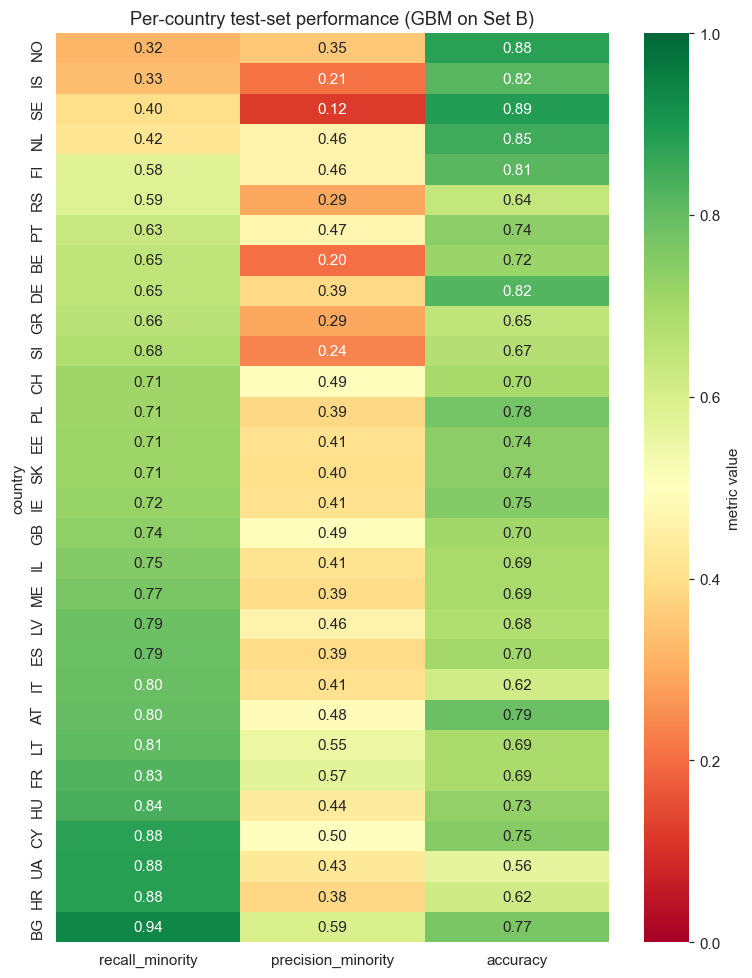

In [19]:
# Heatmap of per-country recall + accuracy + minority precision
to_plot = cntry_table[['recall_minority', 'precision_minority', 'accuracy']].copy()
fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(to_plot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label': 'metric value'}, ax=ax)
ax.set_title(f'Per-country test-set performance ({best_B_algo.upper()} on Set B)')
ax.set_ylabel('country')
plt.tight_layout()
plt.savefig('results/fig5_per_country_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()


## 11.5 Trust-gap descriptive analysis *(CHANGE #4 — supports Results §4.5)*

A 4×4 heatmap of turnout rate by SES quartile × Trust quartile, computed on the test set.

This is **purely descriptive** — no model, no prediction. It lets the report mention the
trust-gap hypothesis honestly:

> *Is the gap between high- and low-trust respondents wider among low-SES respondents (as the
> legitimacy model predicts) or similar across SES levels?*

A formal interaction test would require a logistic regression with `low_SES × high_trust`
terms; we leave that to future work and use this figure to support the descriptive claim.

In [ ]:
# Pull SES-relevant features and trust composite for the test rows
test_rows = set_A.iloc[idx_test].copy()
test_rows['trust_mean'] = test_rows[['trstprl', 'trstplt', 'trstprt', 'trstlgl']].mean(axis=1)

# Composite SES: standardised eduyrs + standardised hinctnta, then averaged
test_rows['ses_z'] = (
    (test_rows['eduyrs']   - test_rows['eduyrs'].mean())   / test_rows['eduyrs'].std()
  + (test_rows['hinctnta'] - test_rows['hinctnta'].mean()) / test_rows['hinctnta'].std()
) / 2

# Quartiles (label 1 = lowest, 4 = highest)
test_rows['ses_q']   = pd.qcut(test_rows['ses_z'],     q=4, labels=[1, 2, 3, 4])
test_rows['trust_q'] = pd.qcut(test_rows['trust_mean'], q=4, labels=[1, 2, 3, 4])

# Cross-tab of mean turnout
turnout_grid = test_rows.groupby(['ses_q', 'trust_q'], observed=True)['vote'].mean().unstack()
turnout_grid.columns.name = 'Trust quartile'
turnout_grid.index.name   = 'SES quartile'

print('Turnout share by SES × Trust quartile (test set):')
print(turnout_grid.round(3))
turnout_grid.to_csv('results/trust_gap_grid.csv')

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(turnout_grid, annot=True, fmt='.2%', cmap='RdYlGn',
            vmin=0.4, vmax=1.0, cbar_kws={'label': 'turnout share'}, ax=ax)
ax.set_title('Turnout share by SES quartile × Trust quartile (test set)')
ax.invert_yaxis()  # so lowest SES at the bottom — reads naturally bottom-to-top
plt.tight_layout()
plt.savefig('results/fig6_trust_gap_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

# The 'trust gap' = high-trust minus low-trust turnout, computed per SES quartile
slopes = (turnout_grid[4] - turnout_grid[1]).rename('high_minus_low_trust_pp')
print('\nTrust gap (high - low trust) by SES quartile:')
print((slopes * 100).round(1).astype(str) + ' pp')

# A larger gap in the low-SES quartile would descriptively SUPPORT the legitimacy model
# (trust matters more for resource-poor citizens). A similar gap across SES levels would
# suggest trust and SES contribute additively rather than interactively.

## 12. Model complexity & runtime (Table 2)

A direct cost-of-complexity comparison vs. the logistic baseline. The report should pair this with PR-AUC to argue whether each step up in complexity is worth its cost.


In [20]:
def model_complexity(estimator, X_test, name):
    """Compute parameter count, on-disk size (KB), and inference latency (µs/sample)
    for an sklearn pipeline."""
    import sys, pickle
    info = {'model': name}
    info['model_size_kb'] = round(sys.getsizeof(pickle.dumps(estimator)) / 1024, 1)
    clf = estimator.named_steps.get('clf', estimator) if hasattr(estimator, 'named_steps') else estimator
    if hasattr(clf, 'coef_'):
        info['n_params'] = int(clf.coef_.size + clf.intercept_.size)
    elif hasattr(clf, 'estimators_'):
        info['n_params'] = sum(t.tree_.node_count for t in (clf.estimators_ if not hasattr(clf.estimators_[0], '__iter__') else clf.estimators_.ravel()))
    else:
        info['n_params'] = None
    t0 = time.time(); _ = estimator.predict_proba(X_test.iloc[:1000])
    info['inference_us_per_sample'] = round((time.time() - t0) * 1e6 / 1000, 1)
    return info

complexity_rows = []
for s, X_test in [('A', X_test_A), ('B', X_test_B)]:
    for algo in ['lr', 'rf', 'gbm']:
        if algo not in models[s]: continue
        info = model_complexity(models[s][algo], X_test, f'{algo.upper()} ({s})')
        complexity_rows.append(info)

complexity_df = pd.DataFrame(complexity_rows)
print(complexity_df.to_string(index=False))
complexity_df.to_csv('results/model_complexity.csv', index=False)

  model  model_size_kb  n_params  inference_us_per_sample
 LR (A)            4.1        51                      7.6
 RF (A)         9661.4    123096                     28.5
GBM (A)          152.1      1500                      2.3
 LR (B)            3.8        44                      1.3
 RF (B)         9791.0    124808                     12.2
GBM (B)          151.9      1500                      1.9


## 13. Direct answers to the research questions

### RQ1 — Which model wins?

The headline number to quote in the report comes from the test-set metrics table (§3) and the ROC/PR curves (§4). Whichever model has the highest **PR-AUC** on the test set wins; ties are broken by minority-class F1.

### RQ2 — Which feature category dominates?

Read the bars in Figure 2 (§7). The category with the largest "drop in PR-AUC when shuffled" is the most predictive. The Discussion should connect the empirical winner back to the Civic Voluntarism Model.

### RQ3 — Which countries are hardest?

Read the bottom of the Figure 5 heatmap (§11). Countries with the lowest minority-class recall are the ones where the model systematically over-predicts voting (or where local political context isn't captured by the individual-level features).

### Headline numbers — exported to `results/summary.json`


In [21]:
# Build a small JSON of headline numbers for the report's Abstract and Conclusion.
top = metrics_df.iloc[0]
summary = {
    'best_model':        top['model'],
    'best_pr_auc':       round(float(top['pr_auc']), 4),
    'best_roc_auc':      round(float(top['roc_auc']), 4),
    'best_accuracy':     round(float(top['accuracy']), 4),
    'best_f1_minority':  round(float(top['f1_minority']), 4),
    'baseline_lr_pr_auc_setA':  round(float(metrics_df.query('algo == "lr" and set == "A"').iloc[0]['pr_auc']), 4),
    'baseline_lr_pr_auc_setB':  round(float(metrics_df.query('algo == "lr" and set == "B"').iloc[0]['pr_auc']), 4),
    'top_category_setA': cat_A.idxmax(),
    'top_category_setB': cat_B.idxmax(),
    'best_country_recall':  float(cntry_table['recall_minority'].max()),
    'worst_country_recall': float(cntry_table['recall_minority'].min()),
    'best_country':         cntry_table['recall_minority'].idxmax(),
    'worst_country':        cntry_table['recall_minority'].idxmin(),
    'n_test':               int(len(y_test)),
    'class_balance':        round(float(y_test.mean()), 3),
}

with open('results/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Headline summary:')
print(json.dumps(summary, indent=2))


Headline summary:
{
  "best_model": "GBM (A)",
  "best_pr_auc": 0.9317,
  "best_roc_auc": 0.8097,
  "best_accuracy": 0.7204,
  "best_f1_minority": 0.5411,
  "baseline_lr_pr_auc_setA": 0.9284,
  "baseline_lr_pr_auc_setB": 0.9285,
  "top_category_setA": "political_interest",
  "top_category_setB": "political_interest",
  "best_country_recall": 0.9369369369369369,
  "worst_country_recall": 0.3157894736842105,
  "best_country": "BG",
  "worst_country": "NO",
  "n_test": 6971,
  "class_balance": 0.781
}


Exception ignored in: <function ResourceTracker.__del__ at 0x106d89760>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1043a1760>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x118abd760>
Traceback (most recent call last

## 14. What's next — writing the report

All the figures and tables for the Word doc are now sitting in `results/`:

```
results/
├── test_metrics.csv             ← Methodology §3.10 / Results Table 1
├── category_importance.csv      ← Results §RQ2
├── variable_importance.csv      ← supplementary
├── per_country_metrics.csv      ← Results §RQ3
├── model_complexity.csv         ← Results Table 2
├── summary.json                 ← Abstract / Conclusion headline numbers
├── fig1_roc_pr_curves.png       ← Results Figure 1
├── fig2_category_importance.png ← Results Figure 2 (RQ2)
├── fig3a_shap_bar.png           ← Results Figure 3a
├── fig3b_shap_summary.png       ← Results Figure 3b
├── fig4_confusion_matrices.png  ← Results Figure 4
├── fig5_per_country_heatmap.png ← Results Figure 5 (RQ3)
├── fig_calibration.png          ← supplementary
├── fig_lr_coefficients.png      ← supplementary
└── fig_variable_importance.png  ← supplementary
```

**Sections of the Word report that are now ready to write:**

- **Abstract** — pull the four headline numbers from `summary.json`.
- **Methodology §3.10 (Evaluation Metrics)** — explain why PR-AUC was chosen; the test-set table is in `test_metrics.csv`.
- **Results — Key Findings** — start with the best-model row, contrast with LR baseline.
- **Results — Actionable Insights** — interpret category-level importance + SHAP.
- **Discussion — Answers to RQ1/RQ2/RQ3** — direct, with numbers.
- **Ethical Consideration** — algorithmic fairness check using per-country and per-age-group recall.
- **Limitations** — self-reported turnout bias (~10–15 pp overstatement), cross-sectional ESS, no political-system features.

Once the Word draft is in shape, the only remaining step is the **5-minute oral-exam slide deck**: one slide each for RQ, methodology, best-model number, top 3 features, ethical caveat.
